In [5]:
import pandas as pd
import numpy as np

In [6]:
drivers_data = pd.read_csv("C:\\Users\\USER\\Desktop\\F1Drivers_Dataset.csv")

drivers_data.head()

,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
0,Carlo Abate,Italy,"[1962, 1963]",0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1960,0.0,0.000000,0.0,0.0,0.0,0.000000,2,False
1,George Abecassis,United Kingdom,"[1951, 1952]",0.0,2.0,2.0,0.0,0.0,0.0,0.0,...,NaN,1950,0.0,1.000000,0.0,0.0,0.0,0.000000,2,False
2,Kenny Acheson,United Kingdom,"[1983, 1985]",0.0,10.0,3.0,0.0,0.0,0.0,0.0,...,NaN,1980,0.0,0.300000,0.0,0.0,0.0,0.000000,2,False
3,Andrea de Adamich,Italy,"[1968, 1970, 1971, 1972, 1973]",0.0,36.0,30.0,0.0,0.0,0.0,0.0,...,NaN,1970,0.0,0.833333,0.0,0.0,0.0,0.166667,5,False
4,Philippe Adams,Belgium,[1994],0.0,2.0,2.0,0.0,0.0,0.0,0.0,...,NaN,1990,0.0,1.000000,0.0,0.0,0.0,0.000000,1,False


Las preguntas son: 

¿Qué nacionalidad tiene la mayor cantidad de pilotos en el dataset y qué tan significativa es su presencia frente a otras nacionalidades?

¿Qué pilotos presentan la mayor tasa de victorias (Win_Rate) y cómo se relaciona este indicador con sus años activos (Years_Active)?

¿Qué década (Decade) presenta en promedio los pilotos más dominantes, considerando la tasa de victorias (Win_Rate)?

¿Cómo se comparan pilotos destacados como Lewis Hamilton, Max Verstappen y Michael Schumacher dentro de la relación entre Pole Positions y Campeonatos?

In [7]:
drivers_data = drivers_data.dropna(subset=['Nationality'])
drivers_data['Nationality'] = drivers_data['Nationality'].str.strip()

nationality_counts = drivers_data.groupby('Nationality')['Driver'].count().sort_values(ascending=False)

nationality_counts.head()

Nationality
United Kingdom    164
United States     160
Italy              99
France             72
West Germany       39
Name: Driver, dtype: int64

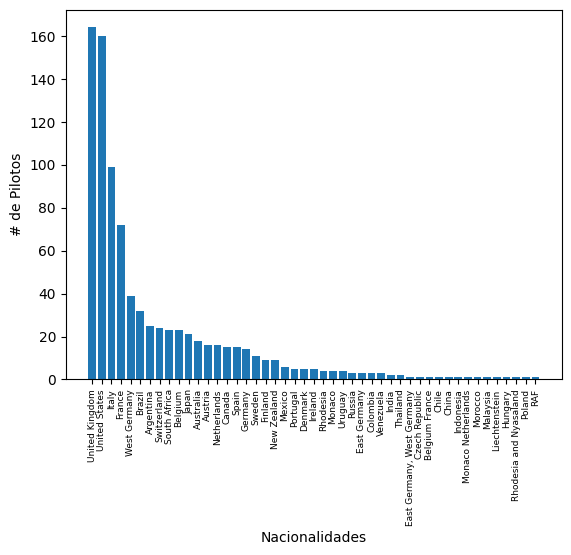

In [8]:
import matplotlib.pyplot as plt
plt.bar(nationality_counts.index, nationality_counts.values)
plt.xticks(rotation=90, fontsize=6.5)
plt.yticks(fontsize=10)
plt.xlabel('Nacionalidades')
plt.ylabel('# de Pilotos')
plt.show()

¿Qué nacionalidad tiene la mayor cantidad de pilotos en el dataset y qué tan significativa es su presencia frente a otras nacionalidades?
RTA:// La nacionalidad con mayor cantidad de pilotos en el dataset es Reino Unido , con 164 pilotos, seguida muy de cerca por Estados Unidos con 160. Posteriormente se encuentran países como Italia (99), Francia (72) y Alemania Occidental (39), mostrando una diferencia más marcada.

Esto indica que existe una alta concentración de pilotos provenientes de unos pocos países, especialmente Reino Unido y Estados Unidos, los cuales dominan claramente la participación en comparación con otras nacionalidades. La diferencia entre los dos primeros lugares es mínima, lo que sugiere una fuerte presencia histórica de ambos países en la Fórmula 1.

Sin embargo, a partir del tercer lugar, la cantidad de pilotos disminuye considerablemente, evidenciando que la representación de otros países es mucho menor. Esto puede estar relacionado con factores como el desarrollo del automovilismo, la inversión en el deporte y la tradición en estas regiones. 

In [9]:

drivers_data = drivers_data.dropna(subset=['Win_Rate', 'Years_Active'])


drivers_data['Win_Rate'] = pd.to_numeric(drivers_data['Win_Rate'], errors='coerce')


drivers_filtered = drivers_data[drivers_data['Years_Active'] > 1]

top_drivers = drivers_filtered.sort_values(by='Win_Rate', ascending=False)

top_drivers[['Driver', 'Win_Rate', 'Years_Active']].head()

,Driver,Win_Rate,Years_Active
238,Juan Manuel Fangio,0.461538,8
35,Alberto Ascari,0.393939,6
169,Jim Clark,0.342466,9
822,Bill Vukovich,0.333333,5
827,Lee Wallard,0.333333,2


In [ ]:
""" plt.bar(top_drivers['Driver'], top_drivers['Win_Rate'])
plt.xticks(rotation=90, fontsize=6.5)
plt.yticks(fontsize=10)
plt.xlabel('Driver')
plt.ylabel('win rate')
plt.show() """

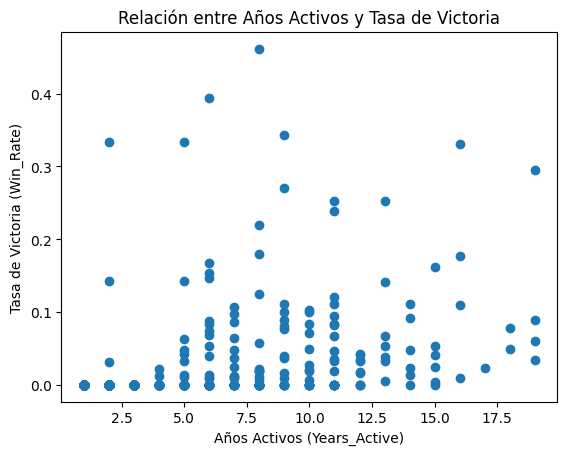

In [10]:
import matplotlib.pyplot as plt

df = drivers_data.dropna(subset=['Win_Rate', 'Years_Active'])

df['Win_Rate'] = pd.to_numeric(df['Win_Rate'], errors='coerce')

# 📊 Gráfico de puntos
plt.figure()
plt.scatter(df['Years_Active'], df['Win_Rate'])

plt.xlabel('Años Activos (Years_Active)')
plt.ylabel('Tasa de Victoria (Win_Rate)')
plt.title('Relación entre Años Activos y Tasa de Victoria')

plt.show()

¿Qué pilotos presentan la mayor tasa de victorias (Win_Rate) y cómo se relaciona este indicador con sus años activos (Years_Active)?

RTA:// A partir de los datos obtenidos, se observa que pilotos como Juan Manuel Fangio y Alberto Ascari presentan las tasas de victoria más altas, con valores de 0.46 y 0.39 respectivamente, a pesar de no tener las trayectorias más largas. De igual forma, otros pilotos como Jim Clark mantienen un alto rendimiento con una combinación equilibrada entre años activos y efectividad.

En contraste, pilotos como Lee Wallard muestran tasas de victoria altas con muy pocos años activos, lo que indica que un alto rendimiento puede lograrse en periodos cortos, aunque no necesariamente se mantiene en el tiempo.

Al relacionar estos resultados con el gráfico de dispersión, se confirma que no existe una relación directa entre los años activos y la tasa de victoria. Los puntos están distribuidos de manera dispersa, sin una tendencia clara, lo que indica que la experiencia (medida en años) no garantiza un mayor porcentaje de victorias.

El rendimiento de los pilotos parece depender más de factores como la calidad del equipo, la época en la que compiten y su desempeño individual, que del tiempo total que permanecen activos en la Fórmula 1.

In [14]:
drivers_data = drivers_data.dropna(subset=['Decade', 'Win_Rate'])

drivers_data['Win_Rate'] = pd.to_numeric(drivers_data['Win_Rate'], errors='coerce')

drivers_data = drivers_data[drivers_data['Win_Rate'] > 0]

decade_win_rate = drivers_data.groupby('Decade')['Win_Rate'].mean().sort_values(ascending=False)

decade_win_rate.head()

Decade
1950    0.197737
1990    0.098504
2010    0.084367
1960    0.083518
1970    0.066596
Name: Win_Rate, dtype: float64

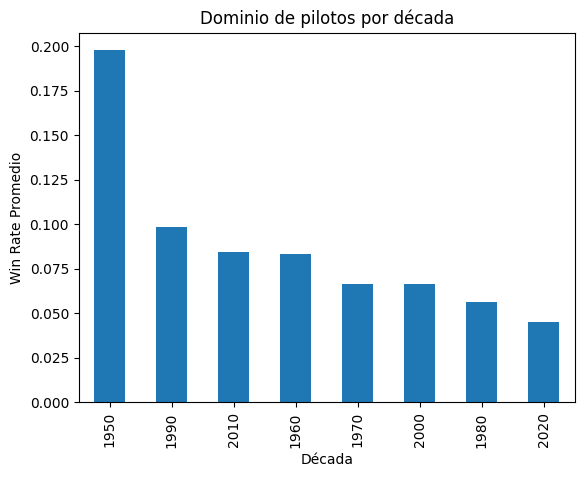

In [ ]:
decade_win_rate = drivers_data.groupby('Decade')['Win_Rate'].mean().sort_values(ascending=False)


plt.figure()
decade_win_rate.plot(kind='bar')

plt.xlabel('Década')
plt.ylabel('Win Rate Promedio')
plt.title('Dominio de pilotos por década')

plt.show()

¿Qué década (Decade) presenta en promedio los pilotos más dominantes, considerando la tasa de victorias (Win_Rate)?
RTA:// A partir del análisis realizado, se observa que la década de 1950 presenta el mayor promedio de tasa de victorias (Win_Rate), con un valor de 0.1977, lo que la convierte en la época con los pilotos más dominantes dentro del dataset.

En comparación, décadas posteriores como 1990 (0.0985), 2010 (0.0843), 1960 (0.0835) y 1970 (0.0666) muestran valores considerablemente menores, lo que indica una disminución en el nivel de dominio individual de los pilotos.

Esta diferencia sugiere que en los años 50 existía una mayor concentración de victorias en pocos pilotos, posiblemente debido a una menor competitividad entre equipos o a una menor cantidad de participantes en la categoría. En cambio, en décadas más recientes, la competencia parece ser más equilibrada, con victorias distribuidas entre un mayor número de pilotos.

En general, el análisis evidencia que el dominio en la Fórmula 1 ha disminuido con el tiempo, dando paso a una competencia más balanceada en las últimas décadas.

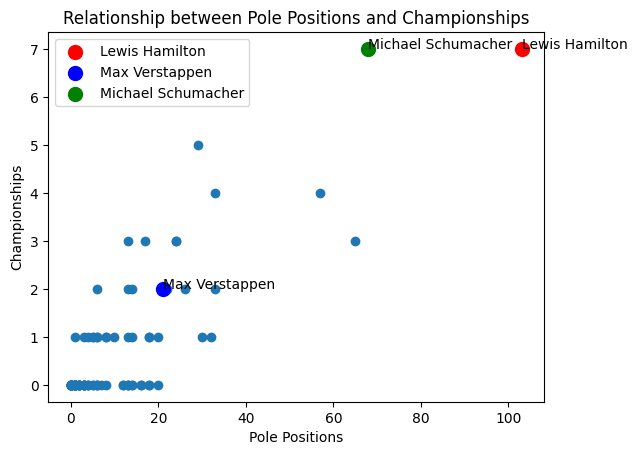

,Driver,Pole_Positions,Championships
338,Lewis Hamilton,103.0,7.0
710,Michael Schumacher,68.0,7.0
811,Max Verstappen,21.0,2.0


In [38]:

df = drivers_data.dropna(subset=['Pole_Positions', 'Championships'])


df['Pole_Positions'] = pd.to_numeric(df['Pole_Positions'], errors='coerce')
df['Championships'] = pd.to_numeric(df['Championships'], errors='coerce')

df[['Driver', 'Pole_Positions', 'Championships']].head()
plt.figure()
plt.scatter(df['Pole_Positions'], df['Championships'])

# Lewis Hamilton
lew_driver = df[(df['Driver'] == 'Lewis Hamilton')]
plt.scatter(lew_driver['Pole_Positions'], lew_driver['Championships'], s=100, color='red', label='Lewis Hamilton')
for i in range(len(lew_driver)):
    plt.text(lew_driver['Pole_Positions'].values[i],
             lew_driver['Championships'].values[i],
             lew_driver['Driver'].values[i])

# Max Verstappen
ver_driver = df[df['Driver'].str.contains('Verstappen', case=False, na=False)]
plt.scatter(ver_driver['Pole_Positions'], ver_driver['Championships'], s=100, color='blue', label='Max Verstappen')
for i in range(len(ver_driver)):
    plt.text(ver_driver['Pole_Positions'].values[i],
             ver_driver['Championships'].values[i],
             ver_driver['Driver'].values[i])

# Michael Schumacher
sch_driver = df[df['Driver'].str.contains('Michael Schumacher', case=False, na=False)]
plt.scatter(sch_driver['Pole_Positions'], sch_driver['Championships'], s=100, color='green', label='Michael Schumacher')
for i in range(len(sch_driver)):
    plt.text(sch_driver['Pole_Positions'].values[i],
             sch_driver['Championships'].values[i],
             sch_driver['Driver'].values[i])

plt.xlabel('Pole Positions')
plt.ylabel('Championships')
plt.title('Relationship between Pole Positions and Championships')
plt.legend()
plt.show()
df[df['Driver'].str.contains('Hamilton|Verstappen|Michael Schumacher', case=False, na=False)][
    ['Driver', 'Pole_Positions', 'Championships']
].head()

¿Cómo se comparan pilotos destacados como Lewis Hamilton, Max Verstappen y Michael Schumacher dentro de la relación entre Pole Positions y Campeonatos?

RTA:// Al analizar pilotos destacados como Lewis Hamilton, Michael Schumacher y Max Verstappen, se observa que existe una relación clara entre el número de pole positions y los campeonatos obtenidos, pero no es proporcional.

Por ejemplo, Hamilton cuenta con 103 pole positions y 7 campeonatos, mientras que Schumacher logró la misma cantidad de campeonatos (7) con solo 68 pole positions. Esto indica que Schumacher tuvo una mayor eficiencia al convertir sus pole positions en títulos.

Por otro lado, Verstappen, con 21 pole positions y 2 campeonatos, sigue la tendencia general: a medida que aumentan las pole positions, también aumentan los campeonatos, aunque su carrera aún es más corta en comparación con los otros pilotos.

Las pole positions influyen en el éxito, pero la eficiencia del piloto y otros factores determinan cuántos campeonatos logra obtener.